# Exploración inicial de datos
## Proyecto final bootcamp - Análisis de cartera S&P 500

In [2]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('2014_Financial_Data.csv')
df.head()

,Unnamed: 0,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,2015 PRICE VAR [%],Class
0,PG,7.440100e+10,-0.0713,3.903000e+10,3.537100e+10,0.000000e+00,2.146100e+10,2.146100e+10,1.391000e+10,7.090000e+08,...,-0.0187,-0.0217,0.0359,0.0316,0.1228,0.0000,-0.1746,Consumer Defensive,-9.323276,0
1,VIPS,3.734148e+09,1.1737,2.805625e+09,9.285226e+08,1.083303e+08,3.441414e+08,7.939267e+08,1.345959e+08,1.214869e+07,...,NaN,NaN,NaN,NaN,NaN,1.6484,1.7313,Consumer Defensive,-25.512193,0
2,KR,9.837500e+10,0.0182,7.813800e+10,2.023700e+10,0.000000e+00,1.519600e+10,1.751200e+10,2.725000e+09,4.430000e+08,...,0.0618,0.0981,0.1886,0.3268,0.2738,0.0000,0.0234,Consumer Defensive,33.118297,1
3,RAD,2.552641e+10,0.0053,1.820268e+10,7.323734e+09,0.000000e+00,6.561162e+09,6.586482e+09,7.372520e+08,4.245910e+08,...,0.0211,-0.0510,-0.0189,0.1963,-0.0458,0.0000,-0.0060,Consumer Defensive,2.752291,1
4,GIS,1.790960e+10,0.0076,1.153980e+10,6.369800e+09,0.000000e+00,3.474300e+09,3.412400e+09,2.957400e+09,3.024000e+08,...,0.0257,0.0090,0.0215,0.0274,0.1025,0.0000,-0.0220,Consumer Defensive,12.897715,1


In [4]:
print("Filas y columnas:", df.shape)

Filas y columnas: (3808, 225)


In [5]:
# Listado de columnas del dataset
df.columns.tolist()

['Unnamed: 0',
 'Revenue',
 'Revenue Growth',
 'Cost of Revenue',
 'Gross Profit',
 'R&D Expenses',
 'SG&A Expense',
 'Operating Expenses',
 'Operating Income',
 'Interest Expense',
 'Earnings before Tax',
 'Income Tax Expense',
 'Net Income - Non-Controlling int',
 'Net Income - Discontinued ops',
 'Net Income',
 'Preferred Dividends',
 'Net Income Com',
 'EPS',
 'EPS Diluted',
 'Weighted Average Shs Out',
 'Weighted Average Shs Out (Dil)',
 'Dividend per Share',
 'Gross Margin',
 'EBITDA Margin',
 'EBIT Margin',
 'Profit Margin',
 'Free Cash Flow margin',
 'EBITDA',
 'EBIT',
 'Consolidated Income',
 'Earnings Before Tax Margin',
 'Net Profit Margin',
 'Cash and cash equivalents',
 'Short-term investments',
 'Cash and short-term investments',
 'Receivables',
 'Inventories',
 'Total current assets',
 'Property, Plant & Equipment Net',
 'Goodwill and Intangible Assets',
 'Long-term investments',
 'Tax assets',
 'Total non-current assets',
 'Total assets',
 'Payables',
 'Short-term debt'

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3808 entries, 0 to 3807
Columns: 225 entries, Unnamed: 0 to Class
dtypes: float64(222), int64(1), object(2)
memory usage: 6.5+ MB


In [7]:
# Columnas relevantes para el proyecto
columnas_interes = [
    'Unnamed: 0',
    'Sector',
    'ROE',
    'Net Profit Margin',
    'Debt to Equity',
    'PE ratio',
    'Revenue Growth',
    '2015 PRICE VAR [%]',
    'Class'
]

# Valores nulos en estas columnas
df[columnas_interes].isnull().sum()

,0
Unnamed: 0,0
Sector,0
ROE,193
Net Profit Margin,57
Debt to Equity,185
PE ratio,154
Revenue Growth,236
2015 PRICE VAR [%],0
Class,0


In [8]:
# Renombramos la columna sin nombre que contiene el ticker
df = df.rename(columns={'Unnamed: 0': 'Ticker'})

df.columns[:3]

Index(['Ticker', 'Revenue', 'Revenue Growth'], dtype='object')

In [9]:
# Creamos un DataFrame reducido con las columnas relevantes
df_limpio = df[[
    'Ticker',
    'Sector',
    'ROE',
    'Net Profit Margin',
    'Debt to Equity',
    'PE ratio',
    'Revenue Growth',
    '2015 PRICE VAR [%]',
    'Class'
]].copy()

print("Dimensiones:", df_limpio.shape)
df_limpio.head()

Dimensiones: (3808, 9)


,Ticker,Sector,ROE,Net Profit Margin,Debt to Equity,PE ratio,Revenue Growth,2015 PRICE VAR [%],Class
0,PG,Consumer Defensive,0.1664,0.1565,0.5061,18.7566,-0.0713,-9.323276,0
1,VIPS,Consumer Defensive,0.3294,0.0364,1.5093,81.5526,1.1737,-25.512193,0
2,KR,Consumer Defensive,0.2821,0.0154,2.1007,12.0340,0.0182,33.118297,1
3,RAD,Consumer Defensive,-0.1180,0.0098,-2.7237,28.6087,0.0053,2.752291,1
4,GIS,Consumer Defensive,0.2792,0.1019,1.3445,18.7034,0.0076,12.897715,1


In [10]:
# Comparamos Class con la variación de precio
df_limpio.groupby('Class')['2015 PRICE VAR [%]'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,2174.0,-29.282228,22.078438,-100.39722,-43.102806,-24.585452,-11.088651,-1.472284e-02
1,1634.0,2311.538401,62552.614621,0.00000,7.343882,16.545995,34.346267,2.418601e+06


In [11]:
# Vemos qué sectores hay y cuántas empresas tiene cada uno
df_limpio['Sector'].value_counts()

,count
Sector,
Financial Services,660
Healthcare,582
Technology,576
Industrials,501
Consumer Cyclical,457
Basic Materials,242
Real Estate,224
Energy,221
Consumer Defensive,165


In [12]:
# Filtramos solo los 4 sectores de nuestro proyecto
sectores_proyecto = ['Technology', 'Energy', 'Healthcare', 'Basic Materials']
df_sectores = df_limpio[df_limpio['Sector'].isin(sectores_proyecto)].copy()

print("Dimensiones:", df_sectores.shape)
df_sectores['Sector'].value_counts()

Dimensiones: (1621, 9)


,count
Sector,
Healthcare,582
Technology,576
Basic Materials,242
Energy,221


In [13]:
# Eliminamos filas con nulos en cualquiera de los KPIs principales
df_sectores = df_sectores.dropna(subset=[
    'ROE',
    'Net Profit Margin',
    'Debt to Equity',
    'PE ratio',
    'Revenue Growth'
])

print("Dimensiones tras eliminar nulos:", df_sectores.shape)
df_sectores['Sector'].value_counts()

Dimensiones tras eliminar nulos: (1535, 9)


,count
Sector,
Technology,554
Healthcare,553
Basic Materials,228
Energy,200


In [14]:
# Estadísticas descriptivas de los KPIs
df_sectores[['ROE', 'Net Profit Margin', 'Debt to Equity', 'PE ratio', 'Revenue Growth']].describe()

,ROE,Net Profit Margin,Debt to Equity,PE ratio,Revenue Growth
count,1535.000000,1535.000000,1535.000000,1535.000000,1535.000000
mean,-0.058888,-7.168927,0.457280,23.945080,2.119653
std,3.806812,60.659975,5.154734,111.250722,42.584206
min,-71.013600,-1505.818200,-70.491000,0.000000,-1.000000
25%,-0.245250,-0.188650,0.000000,0.000000,-0.020950
50%,0.038700,0.006600,0.143900,4.805400,0.056200
75%,0.140950,0.089150,0.566700,23.290200,0.223300
max,71.932300,2.040400,111.452300,3478.000000,1514.578900


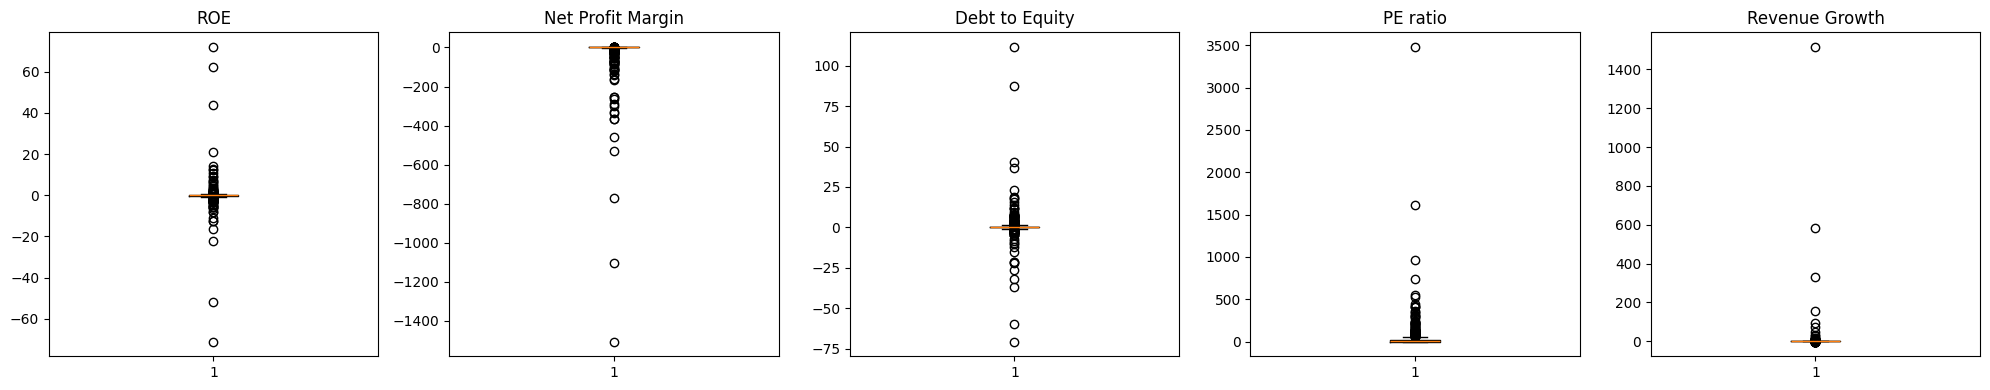

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
kpis = ['ROE', 'Net Profit Margin', 'Debt to Equity', 'PE ratio', 'Revenue Growth']

for i, kpi in enumerate(kpis):
    axes[i].boxplot(df_sectores[kpi])
    axes[i].set_title(kpi)

plt.tight_layout()
plt.show()

In [16]:
# Eliminamos outliers aplicando rangos razonables
df_sectores = df_sectores[
    (df_sectores['ROE'].between(-1, 1)) &
    (df_sectores['Net Profit Margin'].between(-1, 1)) &
    (df_sectores['Debt to Equity'].between(0, 10)) &
    (df_sectores['PE ratio'].between(0, 100)) &
    (df_sectores['Revenue Growth'].between(-1, 5))
]

# Verificamos cuántas empresas nos quedan
print("Dimensiones tras eliminar outliers:", df_sectores.shape)
df_sectores['Sector'].value_counts()

Dimensiones tras eliminar outliers: (1124, 9)


,count
Sector,
Technology,460
Healthcare,292
Basic Materials,194
Energy,178


In [17]:
df_sectores[['ROE', 'Net Profit Margin', 'Debt to Equity', 'PE ratio', 'Revenue Growth']].describe()

,ROE,Net Profit Margin,Debt to Equity,PE ratio,Revenue Growth
count,1124.000000,1124.000000,1124.000000,1124.000000,1124.000000
mean,0.011209,0.012921,0.502525,16.294974,0.132250
std,0.255481,0.215380,0.866040,18.466756,0.365520
min,-0.987800,-0.977000,0.000000,0.000000,-1.000000
25%,-0.071225,-0.016525,0.000000,0.000000,-0.011125
50%,0.066900,0.035450,0.243950,13.500650,0.060950
75%,0.144150,0.117950,0.614125,24.717550,0.191025
max,0.930500,0.721400,9.325900,99.115900,3.012000
